## 0. Import and Definitions

In [1]:
import os
import copy
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA

from src.model.config import VAEConfig
from src.model.build_model import get_model

from src.model.VAE.VAE_model import (
    SCVIMixturePriorWrapper,
    MixturePriorSCVI,
)

from src.model.data_utils import (
    prepare_train_test_data,
    load_data,
    build_metacells,
    prepare_data,
)

from src.analysis.mmd import gaussian_kernel, mmd, ctrl_mmd_dists, mmd_dists, plot_mmd_dists

from src.analysis.logistic_regression import (
    init_classifier, 
    train_classifier, 
    evaluate_cfs_classification, 
    evaluate_training_error, 
    generate_counterfactuals,
)

from src.analysis.analysis_utils import Analyzer
from src.analysis.cf_expressions import plot_mean_expression_comparison, plot_top_deg_violin


## 1. Load Data

In [2]:
dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

USE_METACELLS = False
DONOR = ["Donor1"]

if not USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=["CD4 Memory"],
    )
else:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=None,
        donors=DONOR,
    )
    print(adata.X.shape)
    adata = build_metacells(adata, group_keys=["cell_type", f"{labels_key}"])

dataset_args["top_genes"] = min(adata.shape[1], dataset_args["top_genes"])
adata.obs["cluster_idx"] = adata.obs[f"{labels_key}"].astype("category").cat.codes

## 2. Model

### 2.1 Training

In [4]:
beta = 0.01
lr_means = 1e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = VAEConfig(
    N_dim=adata.X.shape[1],
    means_seperation=4.0,
    trainable_means=True,
    trainable_sigma=False,
    beta=beta,
    lr_means=lr_means,
)

In [22]:
cvae_model, _ = get_model(config, adata)

cvae_model.train(
    max_epochs=300,
    plan_kwargs={"lr_means": lr_means, "means_warmup_epochs": 30},
)

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...


Training:   0%|          | 0/300 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


In [23]:
model_path = "/g/stegle/jhoefer/models/cvae"
cvae_model.model.save(model_path, overwrite=True)
os.rename(model_path + "/model.pt", model_path + f"/{beta}_beta_{lr_means}_lr_means_model.pt")

### 2.2 Loading

In [5]:
model_path = "/g/stegle/jhoefer/models/cvae"
model = MixturePriorSCVI.load(model_path, adata=adata, prefix=f"{beta}_beta_{lr_means}_lr_means_")
cvae_model = SCVIMixturePriorWrapper(model).to(device)

INFO     File /g/stegle/jhoefer/models/cvae/0.01_beta_1e-05_lr_means_model.pt already downloaded                   


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...


## 3. Evaluation

### 3.1 Paths

In [6]:
plot_dir = f"/home/jhoefer/sandbox/results/cvae/plots/{beta}_beta_{lr_means}_lr_means"
csv_dir = f"/home/jhoefer/sandbox/results/cvae/csv/{beta}_beta_{lr_means}_lr_means"
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

### 3.2 Loss

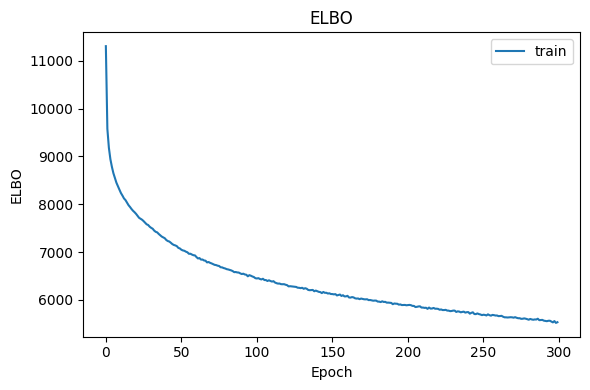

In [7]:
def plot_metric(hist, train_key, title, ylabel, val_key=None):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    if val_key is not None:
        plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{title}.png"))
    plt.show()

hist = cvae_model.model.history
if "elbo_train" in hist:
    plot_metric(hist, "elbo_train", "ELBO","ELBO")

### 3.3 Clusters

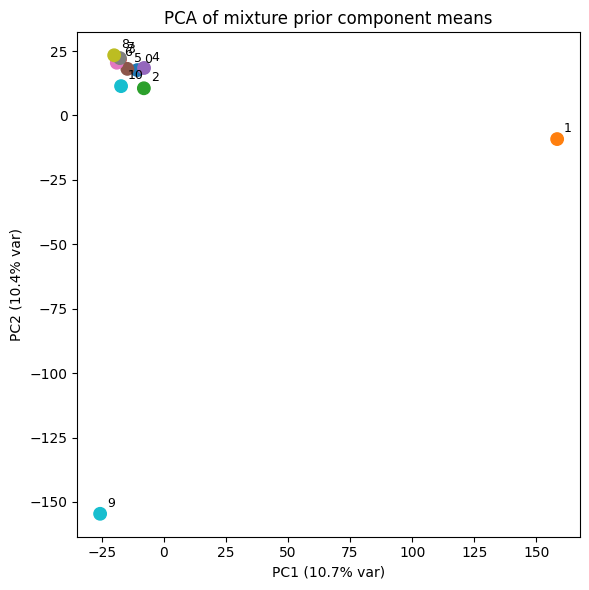

In [8]:
# pull the parameter out to a plain numpy array
means = cvae_model.means_active.detach().cpu().numpy()  # shape: (n_components, n_latent)

# PCA down to 2D
pca = PCA(n_components=2)
means_2d = pca.fit_transform(means)

# plot, labeling each point by its component index
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(means_2d[:, 0], means_2d[:, 1], s=80, c=np.arange(len(means)), cmap="tab10")

for i, (x, y) in enumerate(means_2d):
    ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(5, 5), fontsize=9)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("PCA of mixture prior component means")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "mixture_prior_means_pca.png"))
plt.show()

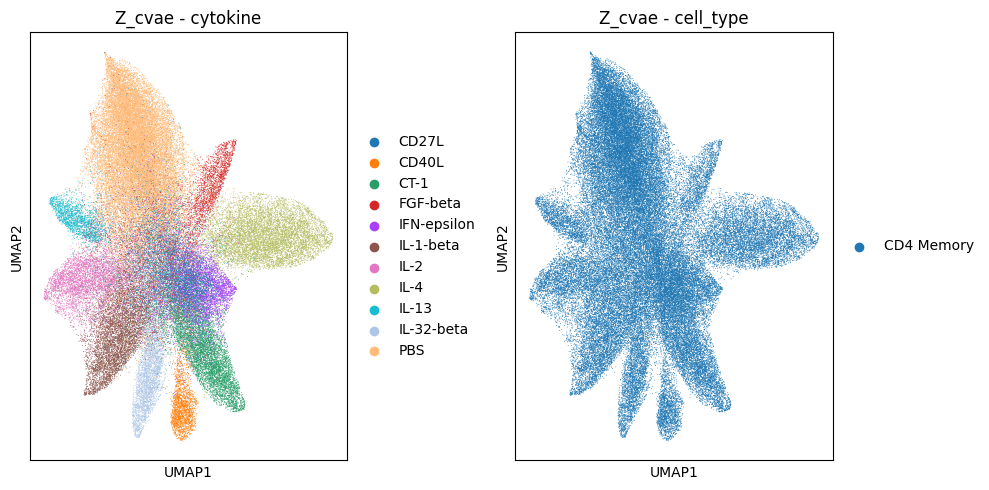

In [9]:
Z_cvae = cvae_model.model.get_latent_representation()
adata.obsm["Z_cvae"] = Z_cvae


reps = ["Z_cvae"]
titles = ["Z_cvae"]

colors = [f"{labels_key}", "cell_type"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for i, rep in enumerate(reps):
    sc.pp.neighbors(adata, use_rep=rep)
    sc.tl.umap(adata)

    for j, color in enumerate(colors):
        sc.pl.umap(
            adata,
            color=color,
            ax=axes[j],
            show=False,
            title=f"{titles[i]} - {color}",
        )

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"latent_umap.png"))
plt.show()

### 3.4 Counterfactuals

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
conditions = [f"{labels_key}"]

dataset, train_dataloader, test_dataset, test_dataloader = prepare_train_test_data(
    adata,
    dataset_args["batch_size"],
    device,
    dtype,
    label_key=conditions,
    test_size=0.1,
)

D_dim = dataset.X.shape[1]
N_dim = cvae_model.module.n_latent

kwargs_data = {
    "device": device,
    "dtype": dtype,
    "N_dim": N_dim,
    "D_dim": D_dim,
    "dataset": dataset,
    "train_dataloader": train_dataloader,
    "test_dataloader": test_dataloader,
    "data_mean": dataset.X.mean(dim=0),
    "data_std": torch.ones(D_dim),
    "sigma_noise": 0.0,
    "sigma_inflate": 0.0,
}

analyzer = Analyzer(
    adata,
    cvae_model,
    kwargs_data,
    labels_key,
    control_label,
    plot_dir,
    csv_dir,
    checkpoint_path=model_path,
    conditions=conditions,
    condition_type="mixture",
)

In [18]:
key = "IL-2"

In [12]:
x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals(analyzer, key=key)

adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
adata_real.obs["origin"] = "original"

adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
adata_cf.X = x_cfs.numpy()
adata_cf.obs["origin"] = "cfs"
adata_cf.obs["source"] = all_source_labels  # keep track of where each cf came from

adata_combined = ad.concat([adata_real, adata_cf])

analyzer_cfs = copy.deepcopy(analyzer)
analyzer_cfs.adata = adata_combined

num_original = adata_real.shape[0]
num_cfs = adata_cf.shape[0]

weights = torch.tensor(
    [1.0 / num_cfs, 1.0 / num_original],
    dtype=torch.float32,
    device=device,
)

weights = weights / weights.sum() * len(weights)

In [13]:
cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, cfs_train_dataset, cfs_adata_train, cfs_num_classes = init_classifier(analyzer_cfs, key=key, latent=False, hidden_dim = None, labels_key="origin")

cfs_accuracies, cfs_train_loss, cfs_val_loss, cfs_class_accuracies = train_classifier(
    cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, weights, analyzer_cfs.device, num_epochs=10
)

100%|████████████████████████████████████████████████████████████| 10/10 [00:10<00:00,  1.06s/it]

Best Validation Accuracy: 0.9999


In [14]:
evaluate_training_error(analyzer, cfs_adata_train, "origin", cfs_num_classes, cfs_class_accuracies)
cats = cfs_train_dataset.cats[0].categories.tolist()
target_idx = cats.index("original")

,Class,Accuracy
0,cfs,0.999929
1,original,1.000000


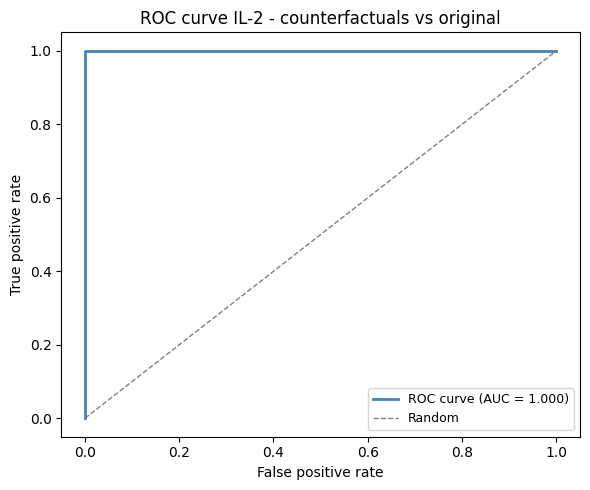

AUC: 1.000


In [15]:
cfs_classifier.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in cfs_test_dataloader:
        x = x.to(analyzer.device)
        logits = cfs_classifier(x)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y[0].argmax(dim=1).cpu().numpy())  # one-hot to int

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# for binary classifier: use probability of positive class
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, target_idx])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curve {key} - counterfactuals vs original")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"roc_curve_{key}.png"), dpi=300)
plt.show()

print(f"AUC: {roc_auc:.3f}")

### 3.5 MMD

In [19]:
ctrl_mmd = ctrl_mmd_dists(analyzer, key=key)
print(f"Control MMD (random split): {ctrl_mmd:.4f}")
global_mmd, mmd_per_group = mmd_dists(analyzer, key=key, sigma=1.0)
print(f"Global MMD for {key}: {global_mmd}")

Control MMD (random split): 0.0003


100%|████████████████████████████████████████████████████████████| 11/11 [00:23<00:00,  2.16s/it]

Global MMD for IL-2: 0.08527040481567383


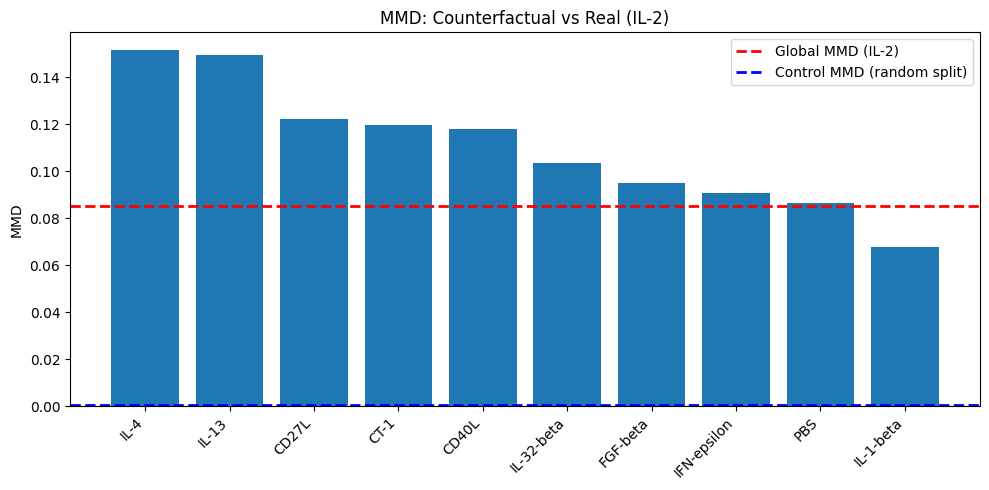

In [20]:
plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key)

### 3.6 Mean Expressions

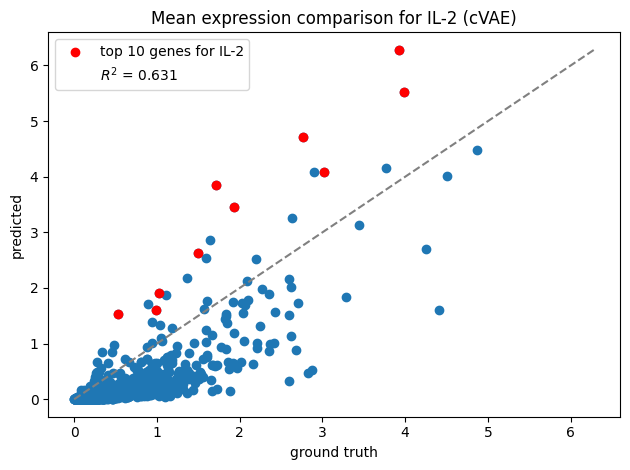

In [21]:
plot_mean_expression_comparison(analyzer, key=key, top_n=10, method="cVAE")

### 3.7 Violin Plots

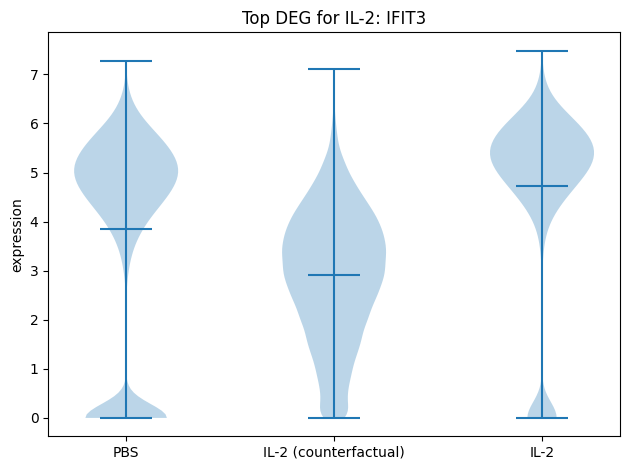

In [22]:
plot_top_deg_violin(analyzer, key=key)